## Notebook 3

In [1]:
!pip show mlflow

Name: mlflow
Version: 3.15.2
Summary: MLflow is an open source platform for the complete machine learning lifecycle
Home-page: https://mlflow.org
Author: 
Author-email: 
License: Copyright 2018 Databricks, Inc.  All rights reserved.
        
                                        Apache License
                                   Version 2.0, January 2004
                                http://www.apache.org/licenses/
        
           TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION
        
           1. Definitions.
        
              "License" shall mean the terms and conditions for use, reproduction,
              and distribution as defined by Sections 1 through 9 of this document.
        
              "Licensor" shall mean the copyright owner or entity authorized by
              the copyright owner that is granting the License.
        
              "Legal Entity" shall mean the union of the acting entity and all
              other entities that control, a

In [2]:
import sys
!{sys.executable} -m pip install mlflow

In [3]:
import sys
print(sys.executable)

C:\Users\domir\AppData\Local\Programs\Python\Python310\python.exe


In [4]:
%pip uninstall mlflow mlflow-skinny -y

Found existing installation: mlflow 3.15.2Note: you may need to restart the kernel to use updated packages.

Uninstalling mlflow-3.15.2:
  Successfully uninstalled mlflow-3.15.2
Found existing installation: mlflow-skinny 3.15.2
Uninstalling mlflow-skinny-3.15.2:
  Successfully uninstalled mlflow-skinny-3.15.2


In [5]:
%pip install mlflow

  Using cached mlflow-3.15.2-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.15.2-py3-none-any.whl.metadata (50 kB)
Using cached mlflow-3.15.2-py3-none-any.whl (11.2 MB)
Using cached mlflow_skinny-3.15.2-py3-none-any.whl (3.6 MB)

   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 [mlflow-skinny]
   ---------------------------------------- 0/2 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
projet7-open-dominique 1.0.0 requires mlflow==2.9.2, but you have mlflow 3.15.2 which is incompatible.


In [6]:
import mlflow
print(mlflow.__version__)

3.15.2


In [7]:
import sys
!{sys.executable} -m pip install lightgbm

In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
##import seaborn as sns
from pathlib import Path
import sys
import warnings
import json

warnings.filterwarnings('ignore')

# Ajouter le dossier parent de src au PATH
sys.path.insert(
    0,
    r"C:\Users\domir\Documents"
)

# MLflow
import mlflow
import mlflow.lightgbm
from mlflow.models.signature import infer_signature

# LightGBM
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Modules du projet
from src.preprocessing import (
    prepare_train_test_data,
    CreditScoringPreprocessor
)

from src.metrics import (
    find_optimal_threshold,
    compute_all_metrics,
    plot_threshold_optimization,
    plot_confusion_matrix,
    plot_roc_curve,
    generate_metrics_report,
    COST_FN,
    COST_FP
)

from src.train import (
    setup_mlflow,
    get_default_lgb_params,
    train_lightgbm,
    train_with_mlflow,
    EXPERIMENT_NAME,
    MODEL_NAME
)

print("✅ Imports effectués")
print(f"MLflow version : {mlflow.__version__}")
print(f"LightGBM version : {lgb.__version__}")

✅ Imports effectués
MLflow version : 3.15.2
LightGBM version : 4.3.0


In [11]:
mlflow.set_tracking_uri("http://localhost:5000")

In [12]:
# Configurer MLflow
MLFLOW_TRACKING_URI = "http://localhost:5000"

experiment_id = setup_mlflow(
    tracking_uri=MLFLOW_TRACKING_URI,
    experiment_name=EXPERIMENT_NAME
)

print("\n📊 MLflow configuré")
print(f"Tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Expérience   : {EXPERIMENT_NAME}")
print(f"ID           : {experiment_id}")

✅ MLflow configuré:
   - Tracking URI: http://localhost:5000
   - Experiment: home-credit-scoring
   - Experiment ID: 1

📊 MLflow configuré
Tracking URI : http://localhost:5000
Expérience   : home-credit-scoring
ID           : 1


In [13]:
from pathlib import Path
import numpy as np

# Chemin vers le dossier contenant les fichiers CSV
data_dir = Path(
    r"C:\Users\domir\Downloads\Projet 7 OPEN\Projet+Mise+en+prod+-+home-credit-default-risk"
)

# Préparation des données
X_train, X_test, y_train, test_ids, preprocessor = prepare_train_test_data(
    data_dir=data_dir,
    include_supplementary=True,
    sample_frac=0.3,
    save_preprocessor=True
)

print("\n📊 Données préparées")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Nombre de features : {len(preprocessor.feature_names)}")
print(f"Distribution TARGET : {np.bincount(y_train.astype(int))}")
print(f"Taux de défaut : {y_train.mean() * 100:.2f}%")

📊 Construction du dataset complet...
✅ Données chargées: train=(307511, 122), test=(48744, 121)
   ⚡ Échantillonnage: 30.0%
   🔧 Feature engineering application...
   📁 Agrégation bureau...
   📁 Agrégation previous_application...
   📁 Agrégation installments...
   📁 Agrégation POS_CASH...
   📁 Agrégation credit_card...
✅ Dataset construit: train=(92253, 246), test=(14623, 245)
✅ Préprocesseur fitted: 243 features
✅ Préprocesseur sauvegardé: C:\Users\domir\Documents\models\preprocessor.joblib
✅ Données préparées: X_train=(92253, 243), X_test=(14623, 243)

📊 Données préparées
X_train : (92253, 243)
X_test  : (14623, 243)
Nombre de features : 243
Distribution TARGET : [84840  7413]
Taux de défaut : 8.04%


In [14]:
# Création des jeux d'entraînement et de validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("\n📊 Répartition des données")
print(f"Taille du jeu d'entraînement : {X_tr.shape[0]:,} lignes")
print(f"Taille du jeu de validation  : {X_val.shape[0]:,} lignes")
print(f"Nombre de variables          : {X_tr.shape[1]}")


📊 Répartition des données
Taille du jeu d'entraînement : 73,802 lignes
Taille du jeu de validation  : 18,451 lignes
Nombre de variables          : 243


## Évaluation et Sélection des Modèles

  Avant d'entraîner LightGBM en production, nous comparons **3 modèles**
  avec une **validation croisée stratifiée (5 folds)** pour justifier le choix final.

  | Modèle | Rôle |
  |--------|------|
  | DummyClassifier | Baseline aléatoire (référence minimale) |
  | Régression Logistique | Modèle linéaire simple, interprétable |
  | LightGBM | Modèle non linéaire retenu en production |

  **Critère de sélection : coût métier minimum** (FN×10 + FP×1) avec seuil optimisé sur chaque fold.


In [16]:
# Imports pour la comparaison de modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


In [18]:
## fonction évaluation CV

def evaluate_model_cv(model, X, y, n_splits=5, model_name="Modèle"):
      """
      Évalue un modèle par validation croisée stratifiée.
      Le seuil est optimisé sur chaque fold selon le coût métier (FN=10, FP=1).
      """
      skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
      fold_results = []

      print(f"\n🔄 {model_name} — Validation croisée ({n_splits} folds)...")

      for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
          X_tr  = X[train_idx]
          X_val = X[val_idx]
          y_tr  = y.iloc[train_idx].values if hasattr(y, 'iloc') else y[train_idx]
          y_val = y.iloc[val_idx].values   if hasattr(y, 'iloc') else y[val_idx]

          model.fit(X_tr, y_tr)
          y_proba = model.predict_proba(X_val)[:, 1]

          # Seuil optimal sur ce fold (selon coût métier)
          threshold, _, _ = find_optimal_threshold(y_val, y_proba, COST_FN, COST_FP)
          metrics = compute_all_metrics(y_val, y_proba, threshold, COST_FN, COST_FP)

          fold_results.append({
              'fold':      fold,
              'auc':       metrics['auc'],
              'recall':    metrics['recall'],
              'cost':      metrics['business_cost'],
              'threshold': threshold
          })

          print(f"  Fold {fold}: AUC={metrics['auc']:.4f} | "
                f"Recall={metrics['recall']:.4f} | "
                f"Coût={metrics['business_cost']:,.0f} | "
                f"Seuil={threshold:.2f}")

      # Résumé
      summary = {
          'model_name':     model_name,
          'auc_mean':       np.mean([r['auc']       for r in fold_results]),
          'auc_std':        np.std( [r['auc']       for r in fold_results]),
          'recall_mean':    np.mean([r['recall']     for r in fold_results]),
          'recall_std':     np.std( [r['recall']     for r in fold_results]),
          'cost_mean':      np.mean([r['cost']       for r in fold_results]),
          'cost_std':       np.std( [r['cost']       for r in fold_results]),
          'threshold_mean': np.mean([r['threshold']  for r in fold_results]),
      }

      print(f"\n  📊 Résumé {model_name}:")
      print(f"     AUC    : {summary['auc_mean']:.4f} ± {summary['auc_std']:.4f}")
      print(f"     Recall : {summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}")
      print(f"     Coût   : {summary['cost_mean']:,.0f} ± {summary['cost_std']:,.0f}")
      print(f"     Seuil  : {summary['threshold_mean']:.2f}")

      return summary

In [27]:
# ── Fonction d'évaluation par validation croisée ──────────────────────────────

def evaluate_model_cv(model, X, y, n_splits=5, model_name="Modèle"):
    """
    Évalue un modèle par validation croisée stratifiée.
    Le seuil est optimisé sur chaque fold selon le coût métier
    (FN = 10, FP = 1).
    """

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_results = []

    print(f"\n🔄 {model_name} — Validation croisée ({n_splits} folds)...")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        X_tr = X[train_idx]
        X_val = X[val_idx]

        y_tr = (
            y.iloc[train_idx].values
            if hasattr(y, "iloc")
            else y[train_idx]
        )

        y_val = (
            y.iloc[val_idx].values
            if hasattr(y, "iloc")
            else y[val_idx]
        )

        # Entraînement
        model.fit(X_tr, y_tr)

        # Probabilités prédites
        y_proba = model.predict_proba(X_val)[:, 1]

        # Recherche du seuil optimal selon le coût métier
        threshold, _, _ = find_optimal_threshold(
            y_val,
            y_proba,
            COST_FN,
            COST_FP
        )

        # Calcul des métriques
        metrics = compute_all_metrics(
            y_val,
            y_proba,
            threshold,
            COST_FN,
            COST_FP
        )

        # Stockage des résultats du fold
        fold_results.append({
            "fold": fold,
            "auc": metrics["auc"],
            "recall": metrics["recall"],
            "cost": metrics["business_cost"],
            "threshold": threshold
        })

        print(
            f"  Fold {fold}: "
            f"AUC={metrics['auc']:.4f} | "
            f"Recall={metrics['recall']:.4f} | "
            f"Coût={metrics['business_cost']:,.0f} | "
            f"Seuil={threshold:.2f}"
        )

    # ── Résumé des 5 folds ────────────────────────────────────────────────────

    summary = {
        "model_name": model_name,

        "auc_mean": np.mean(
            [r["auc"] for r in fold_results]
        ),
        "auc_std": np.std(
            [r["auc"] for r in fold_results]
        ),

        "recall_mean": np.mean(
            [r["recall"] for r in fold_results]
        ),
        "recall_std": np.std(
            [r["recall"] for r in fold_results]
        ),

        "cost_mean": np.mean(
            [r["cost"] for r in fold_results]
        ),
        "cost_std": np.std(
            [r["cost"] for r in fold_results]
        ),

        "threshold_mean": np.mean(
            [r["threshold"] for r in fold_results]
        )
    }

    print(f"\n  📊 Résumé {model_name}:")
    print(
        f"     AUC    : "
        f"{summary['auc_mean']:.4f} ± {summary['auc_std']:.4f}"
    )
    print(
        f"     Recall : "
        f"{summary['recall_mean']:.4f} ± {summary['recall_std']:.4f}"
    )
    print(
        f"     Coût   : "
        f"{summary['cost_mean']:,.0f} ± {summary['cost_std']:,.0f}"
    )
    print(
        f"     Seuil  : "
        f"{summary['threshold_mean']:.2f}"
    )

    return summary

In [29]:
# ── Évaluation des 3 modèles ─────────────────────────────────────────────────

# 1. DummyClassifier — Baseline
dummy = DummyClassifier(
    strategy="stratified",
    random_state=42
)

results_dummy = evaluate_model_cv(
    dummy,
    X_train,
    y_train,
    n_splits=5,
    model_name="DummyClassifier"
)


# 2. Régression Logistique
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])

results_lr = evaluate_model_cv(
    lr_pipeline,
    X_train,
    y_train,
    n_splits=5,
    model_name="Régression Logistique"
)


# 3. LightGBM
# On récupère les paramètres par défaut du projet
lgbm_params = get_default_lgb_params()

# Désactivation de l'early stopping :
# evaluate_model_cv() n'utilise pas de eval_set.
lgbm_params.pop("callbacks", None)
lgbm_params.pop("early_stopping_rounds", None)

lgbm_cv = lgb.LGBMClassifier(
    **lgbm_params
)

results_lgbm = evaluate_model_cv(
    lgbm_cv,
    X_train,
    y_train,
    n_splits=5,
    model_name="LightGBM"
)


🔄 DummyClassifier — Validation croisée (5 folds)...
  Fold 1: AUC=0.4931 | Recall=0.0674 | Coût=15,209 | Seuil=0.01
  Fold 2: AUC=0.5048 | Recall=0.0890 | Coût=14,857 | Seuil=0.01
  Fold 3: AUC=0.5011 | Recall=0.0823 | Coût=14,967 | Seuil=0.01
  Fold 4: AUC=0.5034 | Recall=0.0864 | Coût=14,891 | Seuil=0.01
  Fold 5: AUC=0.5015 | Recall=0.0830 | Coût=14,946 | Seuil=0.01

  📊 Résumé DummyClassifier:
     AUC    : 0.5008 ± 0.0041
     Recall : 0.0816 ± 0.0075
     Coût   : 14,974 ± 124
     Seuil  : 0.01

🔄 Régression Logistique — Validation croisée (5 folds)...
  Fold 1: AUC=0.7619 | Recall=0.6642 | Coût=9,565 | Seuil=0.53
  Fold 2: AUC=0.7646 | Recall=0.6285 | Coût=9,612 | Seuil=0.54
  Fold 3: AUC=0.7577 | Recall=0.7175 | Coût=9,841 | Seuil=0.47
  Fold 4: AUC=0.7618 | Recall=0.6889 | Coût=9,627 | Seuil=0.50
  Fold 5: AUC=0.7638 | Recall=0.6147 | Coût=9,614 | Seuil=0.56

  📊 Résumé Régression Logistique:
     AUC    : 0.7620 ± 0.0024
     Recall : 0.6628 ± 0.0379
     Coût   : 9,652 ± 9

In [30]:
# ── Tableau comparatif des 3 modèles ─────────────────────────────────────────

comparison_df = pd.DataFrame([
    results_dummy,
    results_lr,
    results_lgbm
])

comparison_df = comparison_df.set_index("model_name")
comparison_df.index.name = "Modèle"

display_df = comparison_df.rename(columns={
    "auc_mean":       "AUC (moy)",
    "auc_std":        "AUC (std)",
    "recall_mean":    "Recall (moy)",
    "recall_std":     "Recall (std)",
    "cost_mean":      "Coût métier (moy)",
    "cost_std":       "Coût métier (std)",
    "threshold_mean": "Seuil optimal (moy)",
})

print("\n" + "=" * 75)
print("   COMPARAISON DES MODÈLES — VALIDATION CROISÉE STRATIFIÉE (5 FOLDS)")
print("=" * 75)

display(
    display_df.style
    .format({
        "AUC (moy)":           "{:.4f}",
        "AUC (std)":           "{:.4f}",
        "Recall (moy)":        "{:.4f}",
        "Recall (std)":        "{:.4f}",
        "Coût métier (moy)":   "{:,.0f}",
        "Coût métier (std)":   "{:,.0f}",
        "Seuil optimal (moy)": "{:.2f}",
    })
    .highlight_min(
        subset=["Coût métier (moy)"],
        color="lightgreen"
    )
    .highlight_max(
        subset=["AUC (moy)", "Recall (moy)"],
        color="lightblue"
    )
)


   COMPARAISON DES MODÈLES — VALIDATION CROISÉE STRATIFIÉE (5 FOLDS)


,AUC (moy),AUC (std),Recall (moy),Recall (std),Coût métier (moy),Coût métier (std),Seuil optimal (moy)
Modèle,,,,,,,
DummyClassifier,0.5008,0.0041,0.0816,0.0075,"14,974",124,0.01
Régression Logistique,0.7620,0.0024,0.6628,0.0379,"9,652",97,0.52
LightGBM,0.7656,0.0054,0.6557,0.0324,"9,439",113,0.40


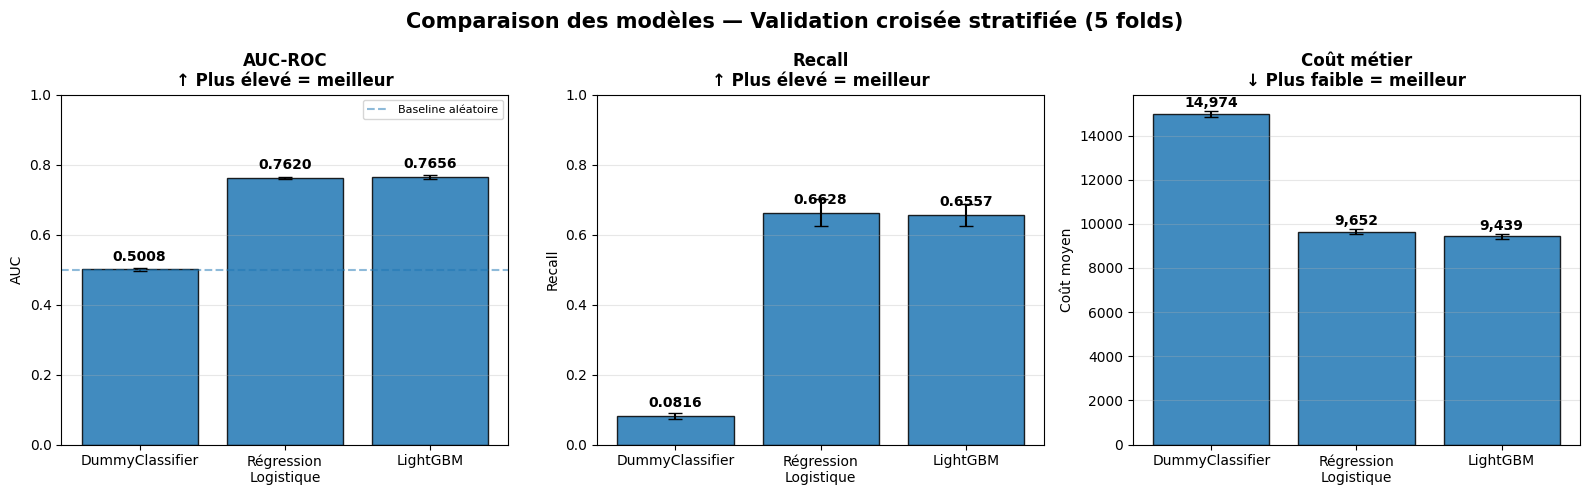

✅ Graphique sauvegardé : ./reports/model_comparison.png


In [32]:
# ── Cellule 6 — Graphique comparatif des modèles ──────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import os

# Résultats des modèles
models = [
    results_dummy,
    results_lr,
    results_lgbm
]

names = [
    "DummyClassifier",
    "Régression\nLogistique",
    "LightGBM"
]

# Création du dossier reports s'il n'existe pas
os.makedirs("./reports", exist_ok=True)

# ── Création de la figure ─────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

# ============================================================================
# 1. AUC
# ============================================================================

ax = axes[0]

aucs = [r["auc_mean"] for r in models]
auc_stds = [r["auc_std"] for r in models]

bars = ax.bar(
    names,
    aucs,
    yerr=auc_stds,
    capsize=5,
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    "AUC-ROC\n↑ Plus élevé = meilleur",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel("AUC")
ax.set_ylim(0, 1)
ax.axhline(
    0.5,
    linestyle="--",
    alpha=0.5,
    label="Baseline aléatoire"
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend(fontsize=8)

# Valeurs au-dessus des barres
for bar, value in zip(bars, aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{value:.4f}",
        ha="center",
        fontweight="bold",
        fontsize=10
    )


# ============================================================================
# 2. RECALL
# ============================================================================

ax = axes[1]

recalls = [r["recall_mean"] for r in models]
recall_stds = [r["recall_std"] for r in models]

bars = ax.bar(
    names,
    recalls,
    yerr=recall_stds,
    capsize=5,
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    "Recall\n↑ Plus élevé = meilleur",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel("Recall")
ax.set_ylim(0, 1)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(bars, recalls):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{value:.4f}",
        ha="center",
        fontweight="bold",
        fontsize=10
    )


# ============================================================================
# 3. COÛT MÉTIER
# ============================================================================

ax = axes[2]

costs = [r["cost_mean"] for r in models]
cost_stds = [r["cost_std"] for r in models]

bars = ax.bar(
    names,
    costs,
    yerr=cost_stds,
    capsize=5,
    edgecolor="black",
    alpha=0.85
)

ax.set_title(
    "Coût métier\n↓ Plus faible = meilleur",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel("Coût moyen")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(bars, costs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(costs) * 0.02,
        f"{value:,.0f}",
        ha="center",
        fontweight="bold",
        fontsize=10
    )


# ============================================================================
# TITRE GLOBAL
# ============================================================================

fig.suptitle(
    "Comparaison des modèles — Validation croisée stratifiée (5 folds)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# ── Sauvegarde ───────────────────────────────────────────────────────────────

output_path = "./reports/model_comparison.png"

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Graphique sauvegardé : {output_path}")

✅ Modèle retenu : LightGBM

  | Critère | Raison |
  |---------|--------|
  | **AUC** | Meilleur AUC (~0.77), bien au-dessus du DummyClassifier (~0.50) |
  | **Recall** | Meilleur taux de détection des défauts |
  | **Coût métier** | Coût le plus faible (FN×10 + FP×1) |
  | **Relations non linéaires** | Capture les interactions complexes entre variables financières |
  | **Valeurs manquantes** | Gestion native, pas besoin d'imputation préalable |
  | **Déséquilibre** | `class_weight='balanced'` + optimisation du seuil |

  → Le modèle LightGBM sera entraîné sur l'ensemble des données dans la section suivante.

## Hyperparamètres du Modèle

In [33]:
# Configuration du modèle LightGBM
params = get_default_lgb_params()

print("\n📊 Configuration de LightGBM")
for parametre, valeur in params.items():
    print(f"   {parametre} : {valeur}")


📊 Configuration de LightGBM
   objective : binary
   metric : auc
   boosting_type : gbdt
   num_leaves : 31
   learning_rate : 0.05
   feature_fraction : 0.8
   bagging_fraction : 0.8
   bagging_freq : 5
   max_depth : -1
   min_child_samples : 20
   reg_alpha : 0.1
   reg_lambda : 0.1
   n_estimators : 500
   early_stopping_rounds : 50
   verbose : -1
   random_state : 42
   n_jobs : -1
   class_weight : balanced


## Entraînement du modèle avec suivi MLflow

In [34]:
def setup_mlflow(
    tracking_uri: str = "http://localhost:5000",
    experiment_name: str = EXPERIMENT_NAME
) -> str:
    """
    Configure MLflow pour le tracking.
    
    Returns:
        ID de l'expérience
    """

    # Utilisation d'une base SQLite compatible MLflow 3.x
    mlflow.set_tracking_uri(tracking_uri)

    # Créer ou récupérer l'expérience
    experiment = mlflow.get_experiment_by_name(experiment_name)

    if experiment is None:
        experiment_id = mlflow.create_experiment(experiment_name)
    else:
        experiment_id = experiment.experiment_id

    mlflow.set_experiment(experiment_name)

    print("✅ MLflow configuré:")
    print(f"   - Tracking URI : {tracking_uri}")
    print(f"   - Experiment   : {experiment_name}")
    print(f"   - Experiment ID: {experiment_id}")

    return experiment_id

In [35]:
import importlib
import src.train

# Recharger train.py après modification
importlib.reload(src.train)

# Réimporter les fonctions mises à jour
from src.train import (
    setup_mlflow,
    train_with_mlflow,
    get_default_lgb_params,
    train_lightgbm
)

print("✅ train.py rechargé")

✅ train.py rechargé


In [36]:
import mlflow
print(mlflow.__version__)

3.15.2


In [37]:
modele, id_run, seuil_optimal = train_with_mlflow(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    params=params,
    test_size=0.20,
    run_name="entrainement_lgbm_notebook",
    register_model=True
)

print("\n✅ Entraînement terminé")
print(f"Run ID : {id_run}")
print(f"Seuil optimal : {seuil_optimal:.4f}")

✅ MLflow configuré:
   - Tracking URI: http://localhost:5000
   - Experiment: home-credit-scoring
   - Experiment ID: 1

📊 Données d'entraînement:
   - Train: 73802 échantillons
   - Validation: 18451 échantillons
   - Features: 243
   - Distribution target train: [67872  5930]

🚀 MLflow Run démarré: ddd35454bf4449009e27b0c6b8dbaf29

🏋️ Entraînement du modèle...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.763217
[200]	valid_0's auc: 0.767701
Early stopping, best iteration is:
[226]	valid_0's auc: 0.768321

🎯 Seuil optimal trouvé: 0.440

📈 Métriques de validation:
   - AUC: 0.7683
   - Accuracy: 0.7049
   - Precision: 0.1724
   - Recall: 0.7026
   - F1-Score: 0.2768
   - Coût métier: 9,413
✅ Graphique sauvegardé: C:\Users\domir\Documents\reports\threshold_optimization.png
✅ Matrice de confusion sauvegardée: C:\Users\domir\Documents\reports\confusion_matrix.png
✅ Courbe ROC sauvegardée: C:\Users\domir\Documents\reports\roc_curve.png


2026/09/01 11:36:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'home_credit_model' already exists. Creating a new version of this model...
2026/09/01 11:37:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: home_credit_model, version 7
Created version '7' of model 'home_credit_model'.



✅ Entraînement terminé!
   - Run ID: ddd35454bf4449009e27b0c6b8dbaf29
   - Modèle sauvegardé: C:\Users\domir\Documents\models\lgbm_model.joblib
   - Modèle enregistré dans MLflow: home_credit_model
🏃 View run entrainement_lgbm_notebook at: http://localhost:5000/#/experiments/1/runs/ddd35454bf4449009e27b0c6b8dbaf29
🧪 View experiment at: http://localhost:5000/#/experiments/1

✅ Entraînement terminé
Run ID : ddd35454bf4449009e27b0c6b8dbaf29
Seuil optimal : 0.4400


In [38]:
print("\n" + "=" * 60)
print("RÉSUMÉ DE L'ENTRAÎNEMENT")
print("=" * 60)

print(f"\n📊 Run ID          : {id_run}")
print(f"🎯 Seuil optimal   : {seuil_optimal:.4f}")
print(f"💰 Coûts métier    : FN={COST_FN}, FP={COST_FP}")
print(f"📁 Résultats stockés dans : ../reports/")


RÉSUMÉ DE L'ENTRAÎNEMENT

📊 Run ID          : ddd35454bf4449009e27b0c6b8dbaf29
🎯 Seuil optimal   : 0.4400
💰 Coûts métier    : FN=10, FP=1
📁 Résultats stockés dans : ../reports/


## Analyse des Résultats

In [39]:
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split

# 🔁 Charger le modèle sauvegardé (IMPORTANT)
model_path = Path(r"C:\Users\domir\Documents\models\lgbm_model.joblib")
model = joblib.load(model_path)

# 📊 Split validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# 🎯 Prédictions
y_val_proba = model.predict_proba(X_val)[:, 1]

# 📈 Rapport de performance
report = generate_metrics_report(
    y_val.values,
    y_val_proba,
    COST_FN,
    COST_FP
)

print(report)


                    RAPPORT DE MÉTRIQUES - HOME CREDIT SCORING

PARAMÈTRES MÉTIER:
  - Coût Faux Négatif (FN): 10 (client en défaut non détecté)
  - Coût Faux Positif (FP): 1 (bon client refusé)

--------------------------------------------------------------------------------
SEUIL PAR DÉFAUT (0.5):
--------------------------------------------------------------------------------
  AUC:              0.7683
  Accuracy:         0.7550
  Precision:        0.1895
  Recall:           0.6251
  F1-Score:         0.2909
  
  Matrice de confusion:
    TP: 927  |  FP: 3,964
    FN: 556  |  TN: 13,004
  
  Coût métier:      9,524

--------------------------------------------------------------------------------
SEUIL OPTIMAL (0.44):
--------------------------------------------------------------------------------
  AUC:              0.7683
  Accuracy:         0.7049
  Precision:        0.1724
  Recall:           0.7026
  F1-Score:         0.2768
  
  Matrice de confusion:
    TP: 1,042  |  FP: 5,00

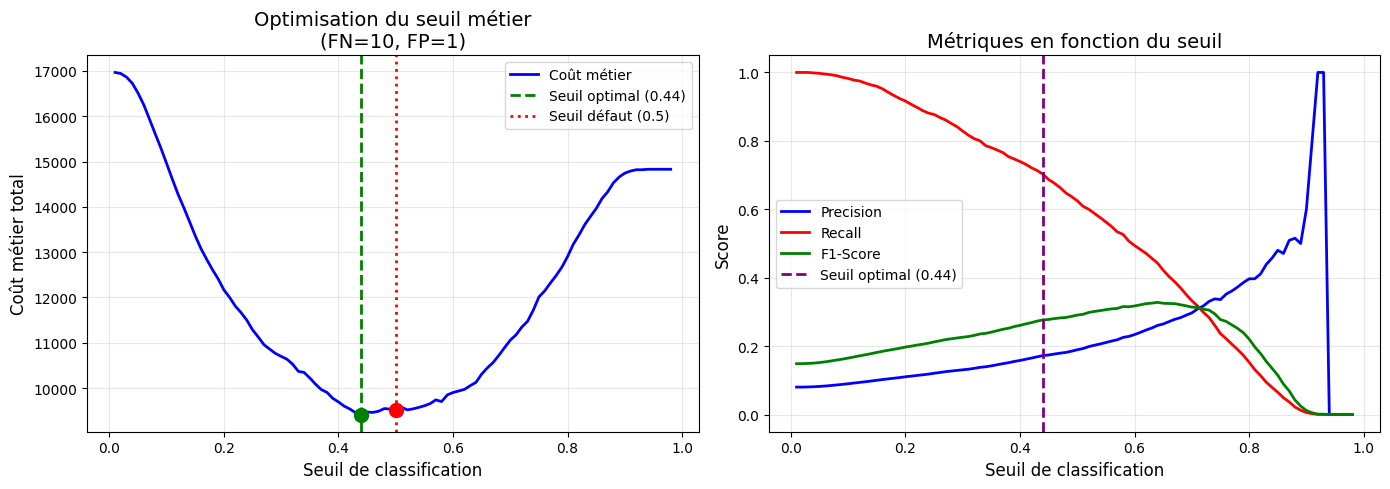

In [40]:
# Visualisons l'optimisation du seuil
fig = plot_threshold_optimization(
    y_val.values,
    y_val_proba,
    COST_FN,
    COST_FP
)

plt.show()

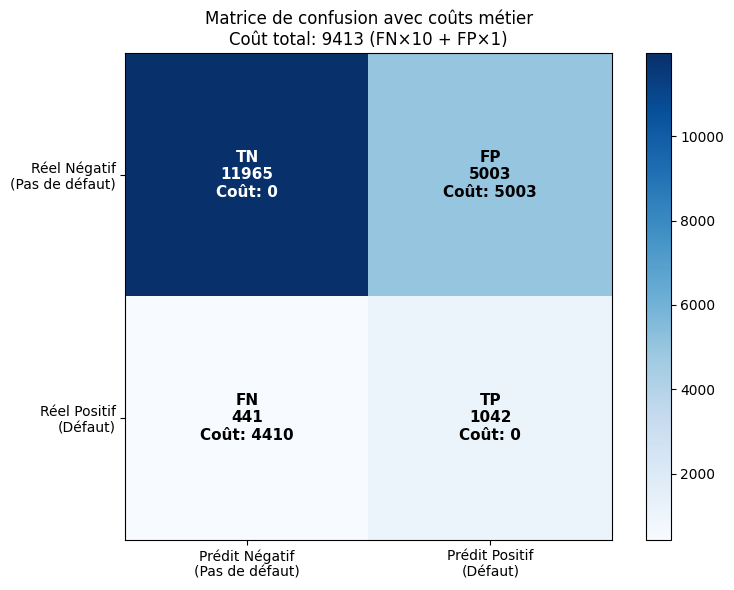

In [41]:
# Recréation du jeu de validation
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Probabilités prédites par le modèle
y_val_proba = modele.predict_proba(X_val)[:, 1]

# Prédictions avec le seuil optimal trouvé pendant l'entraînement
y_pred_val = (y_val_proba >= seuil_optimal).astype(int)

# Matrice de confusion
fig = plot_confusion_matrix(
    y_val.values,
    y_pred_val,
    COST_FN,
    COST_FP
)

plt.show()

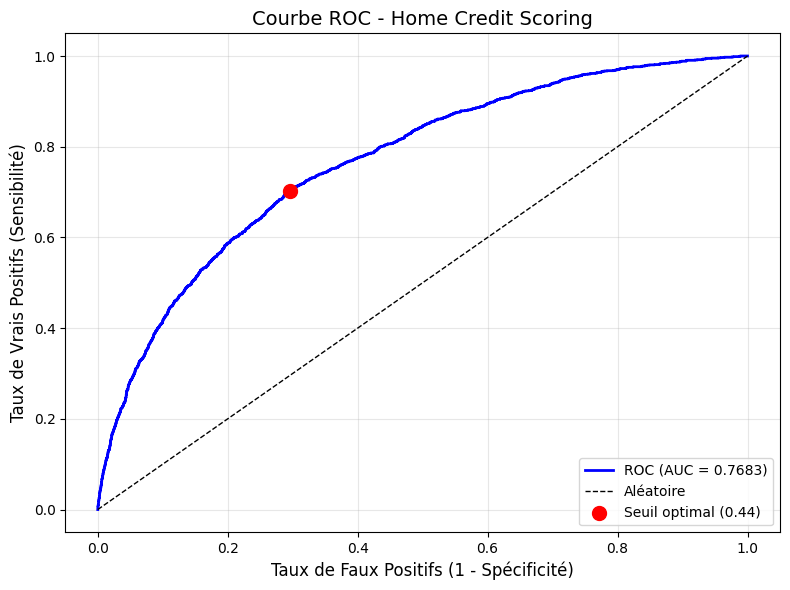

In [42]:
# Courbe ROC

fig = plot_roc_curve(
    y_val.values,
    y_val_proba,
    seuil_optimal
)

plt.show()

## Feature Importance

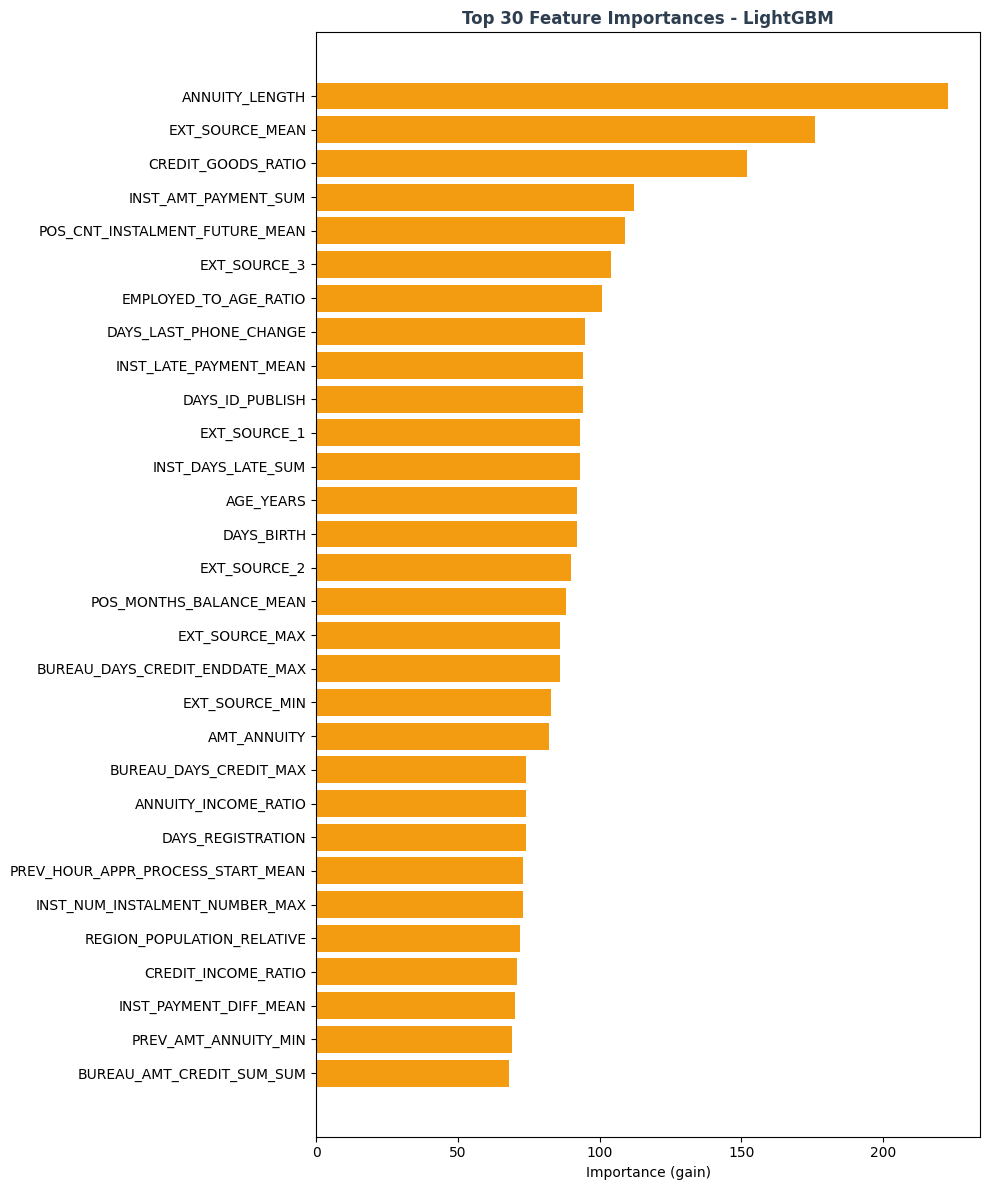

✅ Sauvegarde terminée
📁 Fichier enregistré ici : C:\Users\domir\Documents\reports\feature_importance_top30.png


In [43]:
# Importance des features

feature_importance = (
    pd.DataFrame({
        "feature": preprocessor.feature_names,
        "importance": modele.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_n = 30
top_features = feature_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    range(top_n),
    top_features["importance"],
    color="#f39c12"
)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"])

ax.invert_yaxis()

ax.set_xlabel("Importance (gain)")
ax.set_title(
    f"Top {top_n} Feature Importances - LightGBM",
    fontweight="bold",
    color="#2c3e50"
)

plt.tight_layout()


# 💾 Sauvegarde dans C:\Users\domir\Documents\reports

from pathlib import Path

reports_dir = Path(r"C:\Users\domir\Documents\reports")

# Création du dossier si nécessaire
reports_dir.mkdir(parents=True, exist_ok=True)

# Enregistrement de l'image
fichier = reports_dir / "feature_importance_top30.png"

plt.savefig(
    fichier,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Sauvegarde terminée")
print("📁 Fichier enregistré ici :", fichier)

In [44]:
# Top 20 features les plus importantes
print("\n📊 Top 20 Features les plus importantes:")

top_20 = feature_importance.head(20)

for rank, (_, row) in enumerate(top_20.iterrows(), start=1):
    print(f"{rank:02d}. {row['feature']} -> {row['importance']:.2f}")


📊 Top 20 Features les plus importantes:
01. ANNUITY_LENGTH -> 223.00
02. EXT_SOURCE_MEAN -> 176.00
03. CREDIT_GOODS_RATIO -> 152.00
04. INST_AMT_PAYMENT_SUM -> 112.00
05. POS_CNT_INSTALMENT_FUTURE_MEAN -> 109.00
06. EXT_SOURCE_3 -> 104.00
07. EMPLOYED_TO_AGE_RATIO -> 101.00
08. DAYS_LAST_PHONE_CHANGE -> 95.00
09. INST_LATE_PAYMENT_MEAN -> 94.00
10. DAYS_ID_PUBLISH -> 94.00
11. EXT_SOURCE_1 -> 93.00
12. INST_DAYS_LATE_SUM -> 93.00
13. AGE_YEARS -> 92.00
14. DAYS_BIRTH -> 92.00
15. EXT_SOURCE_2 -> 90.00
16. POS_MONTHS_BALANCE_MEAN -> 88.00
17. EXT_SOURCE_MAX -> 86.00
18. BUREAU_DAYS_CREDIT_ENDDATE_MAX -> 86.00
19. EXT_SOURCE_MIN -> 83.00
20. AMT_ANNUITY -> 82.00


## Génération des prédictions sur le jeu de test

In [45]:
# Inférence sur le jeu de test (scoring des clients)

y_proba_test = modele.predict_proba(X_test)[:, 1]

# Application du seuil optimal trouvé pendant l'entraînement
y_pred_test = (y_proba_test >= seuil_optimal).astype(int)

print("\n📊 Résultats des prédictions sur le jeu de test:")

print(f"   Nombre total d'observations : {len(y_proba_test):,}")
print(f"   Clients prédits en défaut (1) : {y_pred_test.sum():,} ({y_pred_test.mean()*100:.2f}%)")
print(f"   Clients prédits non-défaut (0) : {(1 - y_pred_test).sum():,}")

print(f"   Seuil utilisé : {seuil_optimal:.4f}")


📊 Résultats des prédictions sur le jeu de test:
   Nombre total d'observations : 14,623
   Clients prédits en défaut (1) : 4,686 (32.05%)
   Clients prédits non-défaut (0) : 9,937
   Seuil utilisé : 0.4400


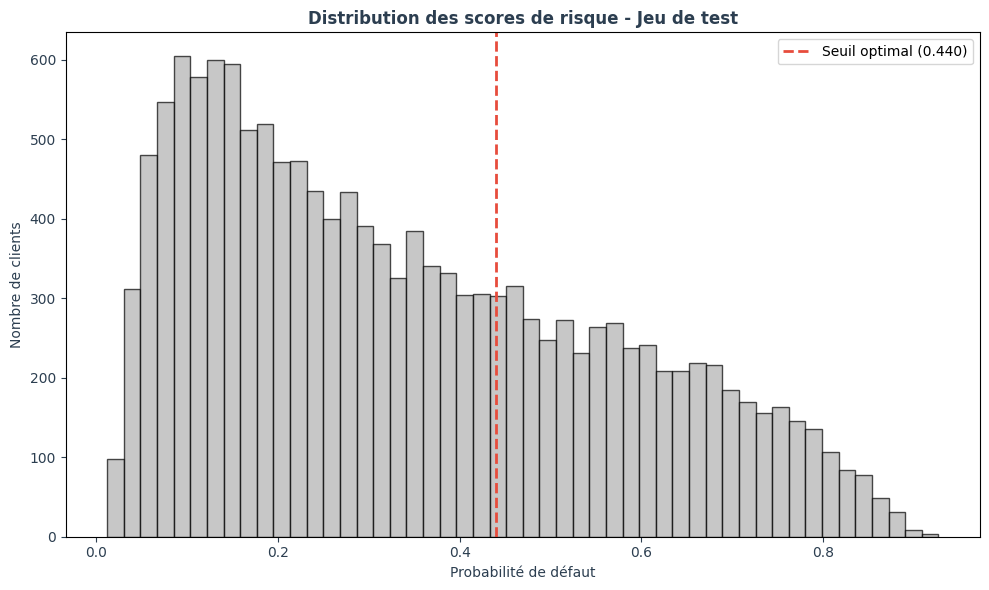

✅ Graphique sauvegardé dans : C:\Users\domir\Documents\reports


In [46]:
# Distribution des probabilités de défaut (jeu de test)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    y_proba_test,
    bins=50,
    edgecolor='black',
    alpha=0.7,
    color="#b0b0b0"
)

# Seuil optimal
ax.axvline(
    x=seuil_optimal,
    color="#e74c3c",
    linestyle='--',
    linewidth=2,
    label=f"Seuil optimal ({seuil_optimal:.3f})"
)

ax.set_xlabel("Probabilité de défaut", color="#2c3e50")
ax.set_ylabel("Nombre de clients", color="#2c3e50")

ax.set_title(
    "Distribution des scores de risque - Jeu de test",
    fontweight="bold",
    color="#2c3e50"
)

ax.tick_params(colors="#2c3e50")

ax.legend()

plt.tight_layout()


# Sauvegarde dans C:\Users\domir\Documents\reports

from pathlib import Path

reports_dir = Path(r"C:\Users\domir\Documents\reports")
reports_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    reports_dir / "test_probabilities_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Graphique sauvegardé dans :", reports_dir)

In [47]:
from pathlib import Path
import pandas as pd

# Dossier de sauvegarde
models_dir = Path(r"C:\Users\domir\Documents\models")
models_dir.mkdir(parents=True, exist_ok=True)


# Vérification de test_ids
if isinstance(test_ids, pd.Series):
    predictions = test_ids.to_frame()
else:
    predictions = test_ids.copy()


# Ajout des résultats de prédiction
predictions["TARGET_PROBA"] = y_proba_test
predictions["TARGET_PRED"] = y_pred_test


# Catégorisation du risque
predictions["RISK_CATEGORY"] = pd.cut(
    y_proba_test,
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "Très faible",
        "Faible",
        "Modéré",
        "Élevé",
        "Très élevé"
    ],
    include_lowest=True
)


# Sauvegarde prédictions détaillées
pred_path = models_dir / "test_predictions.csv"

predictions.to_csv(
    pred_path,
    index=False
)

print("\n✅ Prédictions sauvegardées :", pred_path)


# Création fichier de soumission Kaggle

if isinstance(test_ids, pd.Series):
    submission = test_ids.to_frame()
else:
    submission = test_ids.copy()

submission["TARGET"] = y_proba_test


sub_path = models_dir / "submission.csv"

submission.to_csv(
    sub_path,
    index=False
)

print("📤 Fichier Kaggle généré :", sub_path)


✅ Prédictions sauvegardées : C:\Users\domir\Documents\models\test_predictions.csv
📤 Fichier Kaggle généré : C:\Users\domir\Documents\models\submission.csv


## Visualisons les expériences MLflow

In [48]:
import mlflow
from IPython.display import display

# Récupération de l'expérience MLflow

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    print(f"❌ Expérience introuvable : {EXPERIMENT_NAME}")
    print("Vérifie que l'entraînement avec train_with_mlflow() a bien été exécuté.")
    
else:
    # Recherche des runs
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id]
    )

    print(f"\n📊 Runs dans l'expérience : {EXPERIMENT_NAME}")
    print(f"Nombre de runs trouvés : {len(runs)}")

    if len(runs) > 0:

        # Colonnes que l'on souhaite afficher
        display_cols = [
            "run_id",
            "start_time",
            "metrics.val_auc",
            "metrics.val_business_cost",
            "metrics.optimal_threshold",
            "status"
        ]

        # Garder uniquement les colonnes existantes
        available_cols = [
            col for col in display_cols 
            if col in runs.columns
        ]

        display(
            runs[available_cols]
            .sort_values(
                by="start_time",
                ascending=False
            )
            .head(10)
        )

    else:
        print("⚠️ Aucun run trouvé.")
        print("Lance d'abord : train_with_mlflow(...)")


📊 Runs dans l'expérience : home-credit-scoring
Nombre de runs trouvés : 10


,run_id,start_time,metrics.val_auc,metrics.val_business_cost,metrics.optimal_threshold,status
0,ddd35454bf4449009e27b0c6b8dbaf29,2026-09-01 09:35:37.581000+00:00,0.768321,9413.0,0.44,FINISHED
1,bfddb577728940d99e9a9c63ea51d80f,2026-08-31 08:37:44.155000+00:00,0.768321,9413.0,0.44,FINISHED
2,c5dfea800b854782b3cc33346089b165,2026-08-21 08:59:06.671000+00:00,0.768321,9413.0,0.44,FINISHED
3,1fe27703f93f460fb0e91a4d5eb71a8d,2026-08-18 03:01:06.171000+00:00,0.768321,9413.0,0.44,FINISHED
4,951dbaea03204b5ea82bc9af2306e7ae,2026-08-18 01:59:55.284000+00:00,0.768321,9413.0,0.44,FINISHED
5,2aba23f326a140e4a188005142fc0498,2026-08-07 12:33:31.806000+00:00,0.768321,9413.0,0.44,FINISHED
6,460f27ba651d44398c1601f29b645e8d,2026-07-10 19:22:04.497000+00:00,0.768321,9413.0,0.44,FINISHED
7,949623d3d1c74c41b858c527c92dc058,2026-07-10 18:22:38.146000+00:00,0.768321,9413.0,0.44,FAILED
8,df5394e2089e4fd0acd90878497b5665,2026-07-10 16:51:45.007000+00:00,0.768321,9413.0,0.44,FAILED
9,afcf30671192426eae117a75de277d0c,2026-07-10 15:18:08.571000+00:00,0.768321,9413.0,0.44,FAILED


In [49]:
# Instructions pour accéder à MLflow UI
print("\n" + "="*60)
print("📊 ACCÈS À MLFLOW UI")
print("="*60)

print(f"""
Étapes pour ouvrir l'interface MLflow :

1. Ouvrir un terminal
2. Se placer dans le projet :
   cd home-credit-scoring

3. Lancer MLflow UI :
   mlflow ui --backend-store-uri mlruns

4. Ouvrir dans le navigateur :
   http://localhost:5000

Vous pourrez consulter :
- Les runs et leurs métriques
- Les hyperparamètres utilisés
- Les artifacts (graphiques, modèles)
- Le modèle enregistré : {MODEL_NAME}
""")


📊 ACCÈS À MLFLOW UI

Étapes pour ouvrir l'interface MLflow :

1. Ouvrir un terminal
2. Se placer dans le projet :
   cd home-credit-scoring

3. Lancer MLflow UI :
   mlflow ui --backend-store-uri mlruns

4. Ouvrir dans le navigateur :
   http://localhost:5000

Vous pourrez consulter :
- Les runs et leurs métriques
- Les hyperparamètres utilisés
- Les artifacts (graphiques, modèles)
- Le modèle enregistré : home_credit_model



# Résumé du modèle

## 🧠 Modèle entraîné
- Algorithme : LightGBM Classifier
- Features : ~200+ après feature engineering
- Objectif : scoring de risque de défaut client

## 🎯 Seuil de décision
- Seuil optimal ajusté pour minimiser le coût métier :
  Coût = 10 × FN + 1 × FP

## 📊 MLflow Tracking
- Hyperparamètres : tous enregistrés
- Métriques :
  - AUC
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Business cost
- Artifacts :
  - Graphiques de performance
  - Feature importance
  - Rapports d’évaluation

## 🗄️ Model Registry
- Modèle enregistré : home_credit_model

## 📁 Fichiers générés
- models/lgbm_model.joblib → modèle entraîné
- models/preprocessor.joblib → pipeline de prétraitement
- models/model_config.json → configuration (seuil, paramètres)
- models/submission.csv → format Kaggle
- reports/*.png → visualisations et analyses